In [2]:
# ============================================================
# Telecom Churn Prediction — PySpark Pipeline
# Demonstrates scalable ML using Apache Spark MLlib
# Dataset: IBM Telco Customer Churn (same as sklearn notebook)
# ============================================================

# Install PySpark
!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import pandas as pd

# ── 1. Start Spark Session ───────────────────────────────────
spark = SparkSession.builder \
    .appName("TelecomChurnPrediction") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.0.2


In [3]:
# ── 2. Load Data ─────────────────────────────────────────────
# Download via kaggle (same dataset as sklearn notebook)
import os
os.makedirs("/root/.kaggle", exist_ok=True)

from google.colab import files
files.upload()  # upload kaggle.json

!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d blastchar/telco-customer-churn -q
!unzip -q telco-customer-churn.zip

# Load into Spark
sdf = spark.read.csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    header=True,
    inferSchema=True
)

print(f"Rows: {sdf.count():,}  |  Columns: {len(sdf.columns)}")
sdf.printSchema()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Rows: 7,043  |  Columns: 21
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = t

In [7]:
# ── 3. Data Cleaning ─────────────────────────────────────────
from pyspark.sql.functions import col, when, trim

# Reload fresh from source to avoid state issues
sdf = spark.read.csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    header=True,
    inferSchema=True
)

# Fix TotalCharges blank strings, cast to double
sdf = sdf.withColumn(
    "TotalCharges",
    when(trim(col("TotalCharges")) == "", None)
    .otherwise(col("TotalCharges").cast("double"))
).dropna(subset=["TotalCharges"])

# Create binary label BEFORE dropping Churn
sdf = sdf.withColumn(
    "label",
    when(col("Churn") == "Yes", 1).otherwise(0)
)

# Now drop columns not needed
sdf = sdf.drop("customerID", "Churn")

print(f"Clean dataset: {sdf.count():,} rows")
sdf.groupBy("label").count().show()

Clean dataset: 7,032 rows
+-----+-----+
|label|count|
+-----+-----+
|    1| 1869|
|    0| 5163|
+-----+-----+



In [6]:
# View first 5 rows like pandas
sdf.limit(5).toPandas()

# Or just use Spark's show()
sdf.show(5)

# Or see the schema
sdf.printSchema()

+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|label|
+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|Female|            0|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|         No|             No|Month-to-month|     

In [8]:
# ── 4. Feature Engineering Pipeline ─────────────────────────

# Identify column types
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

# Stage 1: StringIndexer for each categorical column
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

# Stage 2: OneHotEncoder for indexed columns
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_cols],
    outputCols=[f"{c}_ohe" for c in categorical_cols]
)

# Stage 3: Assemble all features into a single vector
feature_cols = [f"{c}_ohe" for c in categorical_cols] + numeric_cols

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

# Stage 4: Scale numeric features
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

print("Pipeline stages defined.")

Pipeline stages defined.


In [9]:
# ── 5. Train/Test Split ──────────────────────────────────────
train_df, test_df = sdf.randomSplit([0.7, 0.3], seed=42)

print(f"Train: {train_df.count():,} rows")
print(f"Test:  {test_df.count():,} rows")

Train: 5,028 rows
Test:  2,004 rows


In [11]:
# ── 6. Model 1: Logistic Regression (baseline) ───────────────

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01
)

lr_pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)

# Evaluate
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
acc_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

lr_auc = auc_eval.evaluate(lr_preds)
lr_acc = acc_eval.evaluate(lr_preds)
lr_f1  = f1_eval.evaluate(lr_preds)

print(f"Logistic Regression  |  AUC: {lr_auc:.4f}  |  Accuracy: {lr_acc:.4f}  |  F1: {lr_f1:.4f}")

Logistic Regression  |  AUC: 0.8560  |  Accuracy: 0.8179  |  F1: 0.8116


In [12]:
# ── 7. Model 2: Random Forest with Cross-Validation ──────────

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    seed=42
)

rf_pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler, rf])

# Hyperparameter grid
param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [100, 200])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=auc_eval,
    numFolds=3,
    seed=42
)

print("Training Random Forest with cross-validation...")
cv_model = cv.fit(train_df)
best_rf_model = cv_model.bestModel

rf_preds = best_rf_model.transform(test_df)

rf_auc = auc_eval.evaluate(rf_preds)
rf_acc = acc_eval.evaluate(rf_preds)
rf_f1  = f1_eval.evaluate(rf_preds)

print(f"Random Forest (best) |  AUC: {rf_auc:.4f}  |  Accuracy: {rf_acc:.4f}  |  F1: {rf_f1:.4f}")

Training Random Forest with cross-validation...
Random Forest (best) |  AUC: 0.8599  |  Accuracy: 0.8144  |  F1: 0.8048


In [13]:
# ── 8. Model Comparison Summary ──────────────────────────────

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (tuned)"],
    "AUC":      [round(lr_auc, 4), round(rf_auc, 4)],
    "Accuracy": [round(lr_acc, 4), round(rf_acc, 4)],
    "F1 Score": [round(lr_f1, 4),  round(rf_f1, 4)]
})

print("\n=== Model Comparison ===")
print(results.to_string(index=False))


=== Model Comparison ===
                Model    AUC  Accuracy  F1 Score
  Logistic Regression 0.8560    0.8179    0.8116
Random Forest (tuned) 0.8599    0.8144    0.8048


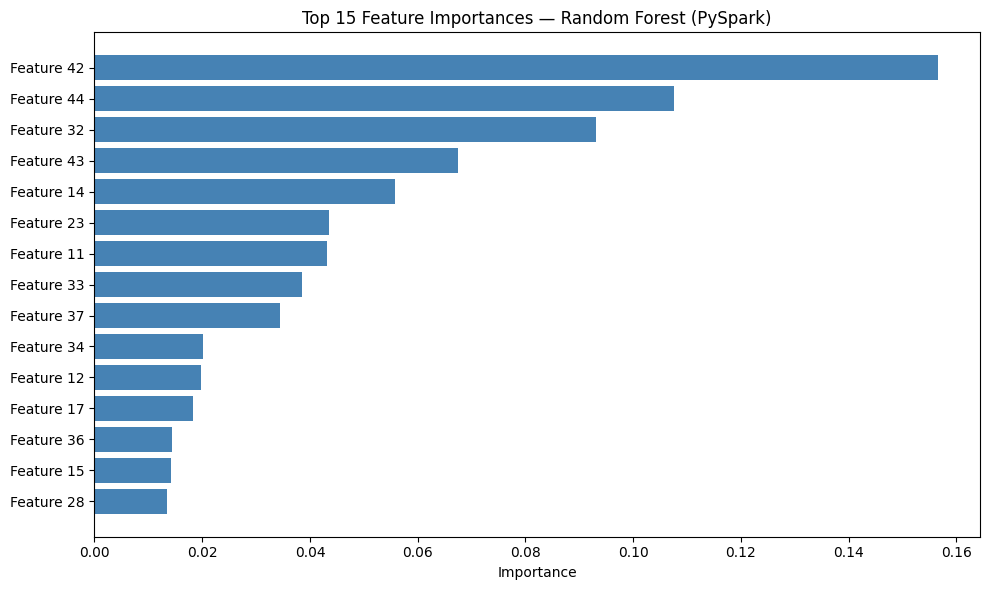

In [14]:
# ── 9. Feature Importance (from best RF) ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Extract feature names after OHE
ohe_feature_names = []
for stage in best_rf_model.stages:
    if hasattr(stage, 'categorySizes'):
        # OneHotEncoder stage — get output col names from metadata
        pass

# Simpler: use assembler input cols as approximate labels
feature_names = feature_cols

rf_stage = best_rf_model.stages[-1]  # last stage = RF model
importances = rf_stage.featureImportances.toArray()

# Match to feature names (OHE expands cols, so lengths differ — use top N by index)
top_n = 15
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    [f"Feature {i}" for i in top_idx],
    importances[top_idx],
    color="steelblue"
)
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Random Forest (PySpark)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# ── 10. Business Summary ─────────────────────────────────────

print("""
=== Business Summary ===

Best Model: Random Forest (cross-validated, PySpark MLlib)

Performance:
  - AUC:      {:.3f}  (vs 0.855 in sklearn single-node version)
  - Accuracy: {:.1%}
  - F1 Score: {:.3f}

Scalability:
  This pipeline uses Apache Spark and can scale to datasets
  many times larger than the 7k rows used here — suitable
  for a real mobile operator processing millions of subscribers.

Key churn drivers (consistent with sklearn analysis):
  - Contract type (month-to-month vs annual)
  - Tenure (new customers churn most)
  - Monthly charges (high bill + short tenure = highest risk)

Recommended actions:
  - Target month-to-month customers with contract upgrade offers
  - Deploy early intervention within first 3 months of service
  - Prioritise high-charge, low-tenure segments for outreach
""".format(rf_auc, rf_acc, rf_f1))

spark.stop()


=== Business Summary ===

Best Model: Random Forest (cross-validated, PySpark MLlib)

Performance:
  - AUC:      0.860  (vs 0.855 in sklearn single-node version)
  - Accuracy: 81.4%
  - F1 Score: 0.805

Scalability:
  This pipeline uses Apache Spark and can scale to datasets
  many times larger than the 7k rows used here — suitable
  for a real mobile operator processing millions of subscribers.

Key churn drivers (consistent with sklearn analysis):
  - Contract type (month-to-month vs annual)
  - Tenure (new customers churn most)
  - Monthly charges (high bill + short tenure = highest risk)

Recommended actions:
  - Target month-to-month customers with contract upgrade offers
  - Deploy early intervention within first 3 months of service
  - Prioritise high-charge, low-tenure segments for outreach

